I used Gemini with the guided learning enabled to help me with understanding, and walking me through the steps to solve everything while asking questions of me and I of it.


# EX5.1

In [2]:
import pandas as pd
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt
import arviz as az

In [3]:
car_mileages = pd.read_csv("passengercarmileage.txt", sep='\t')

car_mileages

,makeAndModel,VOL,HP,MPG,SP,WT
0,GM/GeoMetroXF1,89,49,65.4,96,17.5
1,GM/GeoMetro,92,55,56.0,97,20.0
2,GM/GeoMetroLSI,92,55,55.9,97,20.0
3,SuzukiSwift,92,70,49.0,105,20.0
4,DaihatsuCharade,92,53,46.5,96,20.0
...,...,...,...,...,...,...
77,Mercedes500SL,50,322,18.1,165,45.0
78,Mercedes560SEL,115,238,17.2,140,45.0
79,JaguarXJSConvert,50,263,17.0,147,45.0
80,BMW750IL,119,295,16.7,157,45.0


In [4]:
X = car_mileages["HP"].values
Y = car_mileages["MPG"].values

with pm.Model() as model:
    #weakly informative values
    alpha = pm.Normal("alpha", mu=0, sigma=100)
    beta = pm.Normal("beta", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=10)

    mu = alpha + beta * X
    
    likelihood = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=Y)
    
    trace = pm.sample(draws=1000, tune=1000, return_inferencedata=True)

# Print summary of the parameters (means correspond to regression coefficients)
print(pm.stats.summary(trace, var_names=["alpha", "beta", "sigma"]))

NUTS[nutpie]: [alpha, beta, sigma]


Output()

          mean      sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
alpha    50.09     1.6       48       53     1266     1376  1.00     0.045    0.038
beta   -0.1393  0.0122    -0.16    -0.12     1288     1399  1.00   0.00034  0.00029
sigma     6.25    0.51      5.5      7.1     2255     2280  1.00     0.011   0.0085


Sampling: [y_obs]


Output()

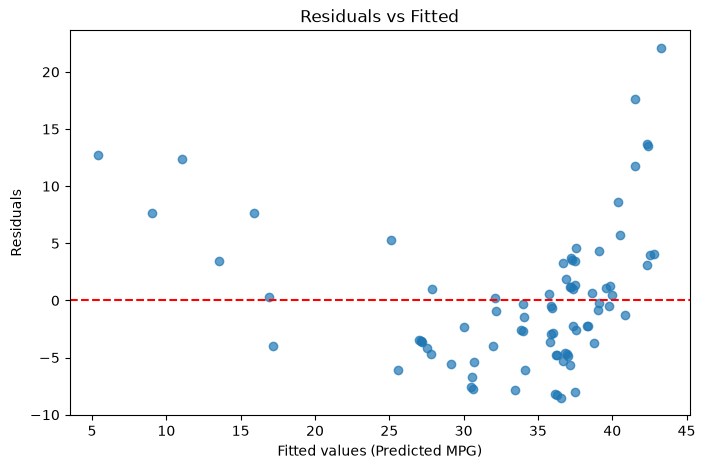

In [5]:
#non-log
with model:
    ppc = pm.sample_posterior_predictive(trace)

#mean predicted values
y_pred = ppc.posterior_predictive["y_obs"].mean(dim=["chain", "draw"]).values
residuals = Y - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values (Predicted MPG)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

#the shape is curved (kind of U-shaped), there isn't a clear linear relationship here.

In [6]:
Y_log = np.log(car_mileages["MPG"].values)

with pm.Model() as log_model:
    #weakly informative values
    alpha = pm.Normal("alpha", mu=0, sigma=100)
    beta = pm.Normal("beta", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=10)

    mu = alpha + beta * X
    
    likelihood = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=Y_log)
    
    trace_log = pm.sample(draws=1000, tune=1000, return_inferencedata=True)

# Print summary of the parameters (means correspond to regression coefficients)
print(pm.stats.summary(trace_log, var_names=["alpha", "beta", "sigma"]))

NUTS[nutpie]: [alpha, beta, sigma]


Output()

           mean       sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
alpha     4.014     0.04      3.9      4.1     1065     1199  1.00    0.0012  0.00089
beta   -0.00459  0.00031  -0.0051  -0.0041     1051     1146  1.00   9.7e-06  6.8e-06
sigma    0.1604   0.0131     0.14     0.18     2336     2345  1.00   0.00027  0.00026


Sampling: [y_obs]


Output()

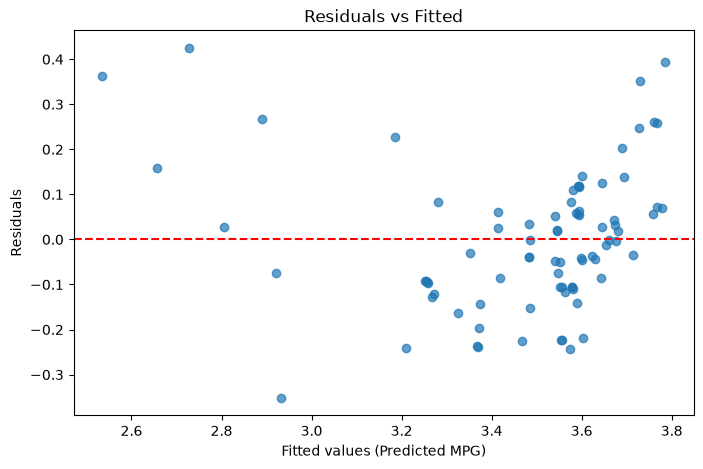

In [10]:
#logged
with model:
    ppc = pm.sample_posterior_predictive(trace_log)

#mean predicted values
y_pred = ppc.posterior_predictive["y_obs"].mean(dim=["chain", "draw"]).values
residuals = Y_log - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values (Predicted MPG)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

#the shape is better, so improved linear relationship, but not perfect

In [30]:
import pymc as pm
import arviz as az

X_multi = car_mileages[["VOL", "HP", "SP", "WT"]].values
Y_multi = car_mileages["MPG"].values

with pm.Model() as flat_model:
    # Completely uninformative flat priors
    alpha = pm.Flat("alpha")
    betas = pm.Flat("betas", shape=X_multi.shape[1])
    sigma = pm.HalfFlat("sigma")

    mu = alpha + pm.math.dot(X_multi, betas)
    likelihood = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=Y_multi)

    trace_flat = pm.sample(draws=3000, tune=1000, random_seed=42, return_inferencedata=True)

# Posterior summary matching Moodle expectations
summary = az.summary(trace_flat, var_names=["alpha", "betas", "sigma"])
print(summary)

NUTS[nutpie]: [alpha, betas, sigma]


Output()

             mean      sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
alpha         192      24      150      230     1550     1497  1.00      0.61     0.52
betas[0]  -0.0154  0.0227   -0.051    0.021     5411     5425  1.00   0.00031  0.00026
betas[1]    0.392   0.082     0.26     0.53     1549     1544  1.00    0.0021   0.0018
betas[2]    -1.29    0.25     -1.7     -0.9     1547     1580  1.00    0.0063   0.0054
betas[3]    -1.86   0.214     -2.2     -1.5     1810     2124  1.00     0.005   0.0039
sigma        3.71   0.309      3.3      4.2     8548     7619  1.00    0.0034   0.0032


In [31]:
# import arviz_stats as az
# r2_summary = az.bayesian_r2(Y_multi, trace_multi)
# print(r2_summary)

# y_pred_multi = trace_multi.posterior_predictive["y_obs"].mean(dim=["chain", "draw"]).values
y_pred_multi = trace_multi.posterior_predictive["y_obs"].mean(dim=["chain", "draw"]).values
ss_res = np.sum((Y_multi - y_pred_multi) ** 2)
ss_tot = np.sum((Y_multi - np.mean(Y_multi)) ** 2)
r2_multi = 1 - (ss_res / ss_tot)

print("Multiple Model R²:", r2_multi)


Multiple Model R²: 0.8699487569301637


betas[0] (VOL - Volume): $\frac{-0.0154}{0.0227} \approx -0.68$ (Insignificant; 89% interval includes 0: $[-0.051, 0.021]$)

betas[1] (HP - Horsepower): $\frac{0.392}{0.082} \approx 4.78$ (Strong certainty/strength)

betas[2] (SP - Speed): $\frac{-1.29}{0.25} \approx -5.16$ (Strong certainty/strength)

betas[3] (WT - Weight): $\frac{-1.86}{0.214} \approx -8.69$ (Very high certainty/strength)


### Personal notes
-  outcome $y$ as a Normal distribution centered on our line:$$\text{MPG}_i \sim \text{Normal}(\mu_i, \sigma)$$$$\mu_i = \alpha + \beta \cdot \text{HP}_i$$
-  Posterior Predictive Checks (PPC) to compute the predicted values ($\hat{y}$) and calculate the residuals
-  Heteroscedasticity means that the variance of errors or residuals in a statistical model is not constant across the values of an independent variable

# Ex5.2

1. Least Squares Estimate

residuals:
$$e_i = Y_i - \beta X_i$$

$$RSS = \sum_{i=1}^n (Y_i - \beta X_i)^2$$


Chain rule:

$u = Y_i - \beta X_i$

$\frac{d}{du} = 2u$
$\frac{d}{d\beta} = -X_i$

$\frac{d}{du} * \frac{d}{\beta} = -2X_iu
=-2X_i(Y_i - \beta X_i)$


$$\frac{dRSS}{d\beta} = \sum_{i=1}^n -2 X_i (Y_i - \beta X_i)$$

$$ -2\sum_{i=1}^n (X_iY_i - \beta X_i^2)$$

$$\sum_{i=1}^n X_i Y_i - \sum_{i=1}^n \beta X_i^2 = 0$$

$$\sum_{i=1}^n X_i Y_i - \beta \sum_{i=1}^n X_i^2$$

Estimator: $\hat\beta$
$$\hat\beta = \frac{-\sum_{i=1}^n X_i Y_i}{-\sum_{i=1}^n X_i^2}$$
$$ = \frac{\sum_{i=1}^n X_i Y_i}{\sum_{i=1}^n X_i^2}$$

2. Bias of an estimator

$$\text{Bias}(\hat{\beta}) = \mathbb{E}(\hat{\beta}) - \beta$$



$Y_i = \beta X_i + \epsilon_i$

$$\hat{\beta} = \frac{\sum_{i=1}^n X_i (\beta X_i + \epsilon_i)}{\sum_{i=1}^n X_i^2}$$

$$= \frac{\sum_{i=1}^n \beta X_i^2 + \epsilon_i X_i}{\sum_{i=1}^n X_i^2}$$

$$= \frac{\beta\sum_{i=1}^n X_i^2}{\sum_{i=1}^n X_i^2} + \frac{\sum_{i=1}^n X_i \epsilon_i}{\sum_{i=1}^n X_i^2}$$

$$= \beta + \frac{\sum_{i=1}^n X_i \epsilon_i}{\sum_{i=1}^n X_i^2}$$


Given: $\mathbb{E}(X_i \epsilon_i) = 0$ for all $i$
$$\mathbb{E}(\hat{\beta}) = \mathbb{E}\left(\beta + \frac{\sum_{i=1}^n X_i \epsilon_i}{\sum_{i=1}^n X_i^2}\right)$$

$$= \beta + \mathbb{E}\left(\frac{\sum_{i=1}^n X_i \epsilon_i}{\sum_{i=1}^n X_i^2}\right)$$

$$= \beta + 0 = \beta$$


$$\text{Bias}(\hat{\beta}) = \mathbb{E}(\hat{\beta}) - \beta = \beta - \beta = 0$$



### personal notes
- $Y_i = \beta X_i + \epsilon_i$ -- forced to pass through the origin since $\beta_0$ isn't present
- In regular regression with an intercept, the slope is $\frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sum (X_i - \bar{X})^2}$
- Expectation is linear

# Ex5.3

NUTS[nutpie]: [theta]


Output()

        mean     sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
theta  0.132  0.193    -0.18     0.44     3519     4811  1.00    0.0032  0.0021


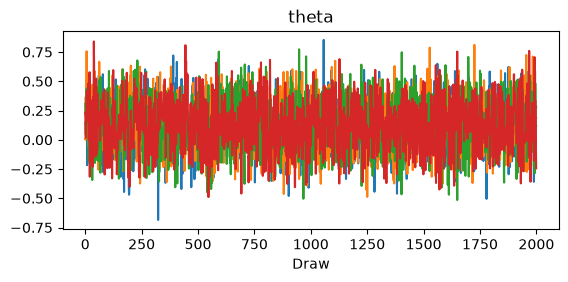

In [104]:
import pymc as pm
import numpy as np
import arviz as az  # Used for posterior analysis and diagnostics

# 1. Load Data
X_data = np.array([
    -0.02, -0.03, 0.82, -1.05, -0.76, 0.46, -0.06, 0.34, -0.08, -0.24, 
     1.43,  1.07, -2.5 ,  1.48,  2.16, 1.23, -0.21, -0.69, 0.73, -0.62
])

sigma_known = 1.0
theta_mean = 0.0
theta_std = 0.4  # Notice std = sqrt(0.4^2) = 0.4

# 2. Build Model
with pm.Model() as model_part_a:
    # Prior for theta: N(0, 0.4^2)
    theta = pm.Normal('theta', mu=theta_mean, sigma=theta_std)
    
    # Likelihood: X ~ N(theta, 1^2)
    X_obs = pm.Normal('X_obs', mu=theta, sigma=sigma_known, observed=X_data)
    
    # 3. Sample from Posterior
    idata_a = pm.sample(draws=2000, tune=1000, random_seed=42)

# 4. Check Results and Diagnostics
az.plot_trace(idata_a)
summary_a = az.summary(idata_a, var_names=['theta'])
print(summary_a)

NUTS[nutpie]: [theta, sigma]


Output()

        mean     sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
theta  0.127  0.209     -0.2     0.46     6988     5583  1.00    0.0025  0.0026
sigma  1.089  0.177     0.85      1.4     7377     5698  1.00    0.0021  0.0026


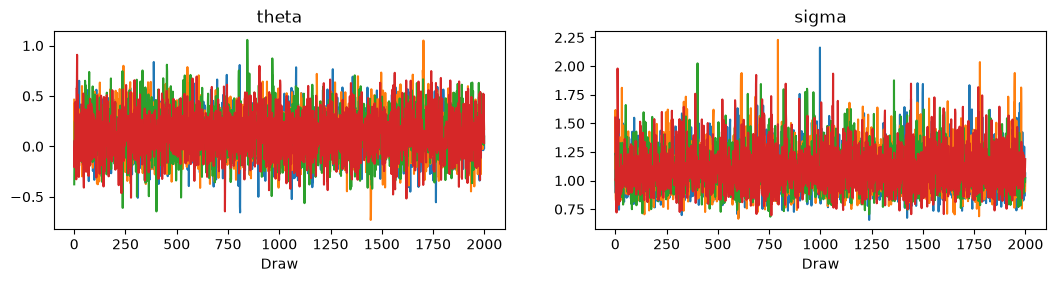

In [105]:
with pm.Model() as model_part_b:
    # Prior for theta: N(0, 0.4^2)
    theta = pm.Normal('theta', mu=0.0, sigma=0.4)
    
    # Prior for sigma: Gamma(alpha=2, beta=2)
    sigma = pm.Gamma('sigma', alpha=2.0, beta=2.0)
    
    # Likelihood using the random parameter sigma
    X_obs = pm.Normal('X_obs', mu=theta, sigma=sigma, observed=X_data)
    
    # Sample from the joint posterior
    idata_b = pm.sample(draws=2000, tune=1000, random_seed=42)

# Diagnostics and summary for both parameters
az.plot_trace(idata_b)
summary_b = az.summary(idata_b, var_names=['theta', 'sigma'])
print(summary_b)

### personal notes
- The thetas are about the same in both cases. With the unknown $\sigma$ case's std being ever so slightly higher than in the known case.
- eti89_lb / eti89_ub: equal-tailed interval. tells the 89% confidence of what range the true value lies in (in this case $\theta$)
- ess_bulk / ess_tail: Effective sample size. estimate of independent draws.
- r_hat: Gelmans-rubin diagnostic ($\hat R$). Convergence measure across chains, value less than 1.05 signifies good mixing.
- mcse_mean / mcse_sd: Monnte Carlo Standard Error. Estimation error of MCMC sampling.
- A good plot looks like a caterpillar. Overlapping colors, noise stays stationary.

In [106]:
# Proportion of sampled theta values that are greater than 0
prob_greater_than_zero = (idata_a.posterior['theta'] > 0).mean().values
print(prob_greater_than_zero)

0.760375


# Ex5.4



NUTS[nutpie]: [beta0, beta1, sigma]


Output()

        mean    sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
beta0   0.25  0.85     -1.1      1.6     3187     4080  1.00     0.015  0.0097
beta1  0.788  0.17     0.52      1.1     2907     3909  1.00    0.0032  0.0022
sigma   2.34  0.51      1.7      3.2     4148     4493  1.00    0.0083    0.01


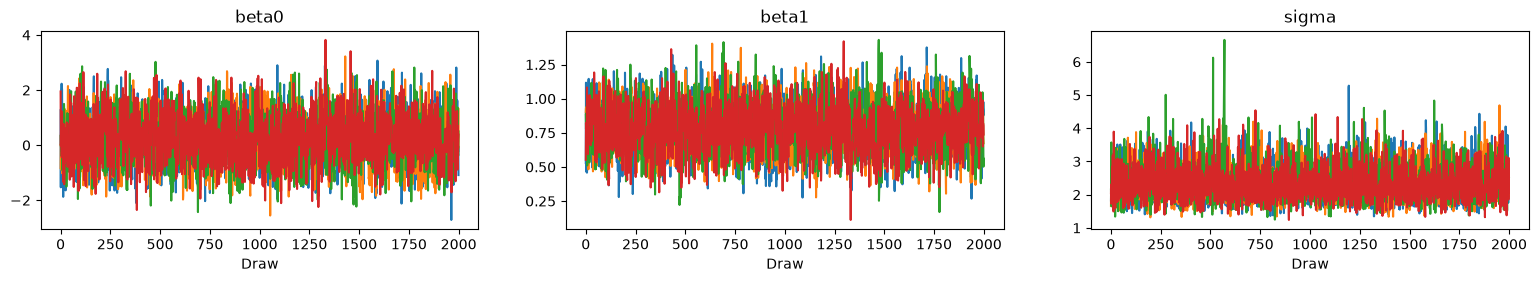

In [16]:
# --- Data and Hyperparameters ---
# The data for the exercise
X_data = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0])
Y_data = np.array([1.06, 2.07, 2.97, 4.01, 5.13, 5.92, 6.91, 0.00, 9.15, 9.90])

# Prior hyperparameters
beta_mean = 0.0
beta_std = 1.0
sigma_alpha = 0.1
sigma_beta = 1.0

# --- Model Definition ---
with pm.Model() as linear_model:
    # Priors for the intercept (beta0) and slope (beta1)
    beta0 = pm.Normal('beta0', mu=beta_mean, sigma=beta_std)
    beta1 = pm.Normal('beta1', mu=beta_mean, sigma=beta_std)
    
    # Prior for the noise standard deviation
    sigma = pm.Gamma('sigma', alpha=sigma_alpha, beta=sigma_beta)
    
    # Expected value of Y
    mu = beta0 + beta1 * X_data
    
    # Likelihood of the data
    Y_obs = pm.Normal('Y_obs', mu=mu, sigma=sigma, observed=Y_data)
    idata = pm.sample(draws=2000, return_inferencedata=True)

az.plot_trace(idata)
summary = az.summary(idata, var_names=['beta0', 'beta1', 'sigma'])
print(summary)
#the convergence succeeded despite the outlier, though the slope and intercept suffered slightly

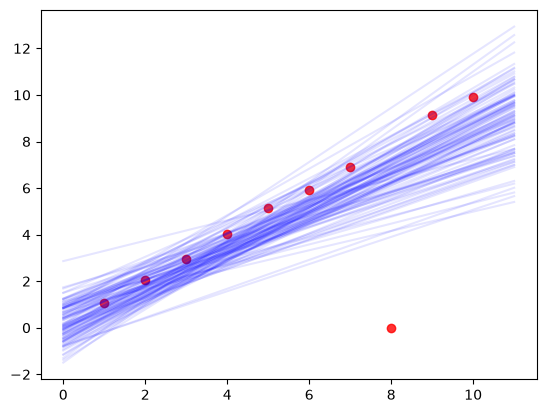

In [17]:
posterior_beta0 = idata.posterior['beta0'].values.flatten()
posterior_beta1 = idata.posterior['beta1'].values.flatten()

indices = np.random.choice(len(posterior_beta0), size=100, replace=False)

# Plot each line
x_vals = np.linspace(0, 11, 100)
for idx in indices:
    b0 = posterior_beta0[idx]
    b1 = posterior_beta1[idx]
    plt.plot(x_vals, b0 + b1 * x_vals, color='blue', alpha=0.1)

plt.scatter(X_data, Y_data, color='red', alpha=0.8)
#there's a lot of variation for the lines, many are clearly bad fits
#only some lines are decent
#showing that if we randomly pick lines a lot of them likely to be bad

NUTS[nutpie]: [beta0, beta1, sigma]


Output()

         mean     sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
beta0   0.063  0.106   -0.094     0.22     1720     2059  1.00    0.0027   0.005
beta1  0.9885  0.019     0.96        1     1749     2209  1.00   0.00047  0.0007
sigma   0.138  0.073    0.064     0.26     2007     2514  1.00    0.0016  0.0032


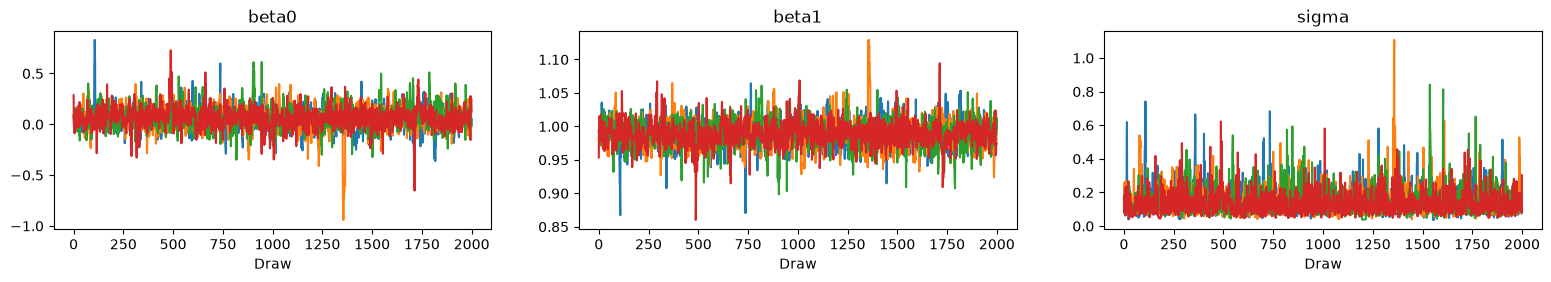

In [5]:
# --- Data and Hyperparameters ---
# The data for the exercise
X_data = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0])
Y_data = np.array([1.06, 2.07, 2.97, 4.01, 5.13, 5.92, 6.91, 0.00, 9.15, 9.90])

# Prior hyperparameters
beta_mean = 0.0
beta_std = 1.0
sigma_alpha = 0.1
sigma_beta = 1.0
nu = 3

# --- Model Definition ---
with pm.Model() as linear_model:
    # Priors for the intercept (beta0) and slope (beta1)
    beta0 = pm.Normal('beta0', mu=beta_mean, sigma=beta_std)
    beta1 = pm.Normal('beta1', mu=beta_mean, sigma=beta_std)
    
    # Prior for the noise standard deviation
    sigma = pm.Gamma('sigma', alpha=sigma_alpha, beta=sigma_beta)
    
    # Expected value of Y
    mu = beta0 + beta1 * X_data
    
    # Likelihood of the data
    Y_obs = pm.StudentT('Y_obs', nu=nu, mu=mu, sigma=sigma, observed=Y_data)
    idata = pm.sample(draws=2000, return_inferencedata=True)

az.plot_trace(idata)
summary = az.summary(idata, var_names=['beta0', 'beta1', 'sigma'])
print(summary)

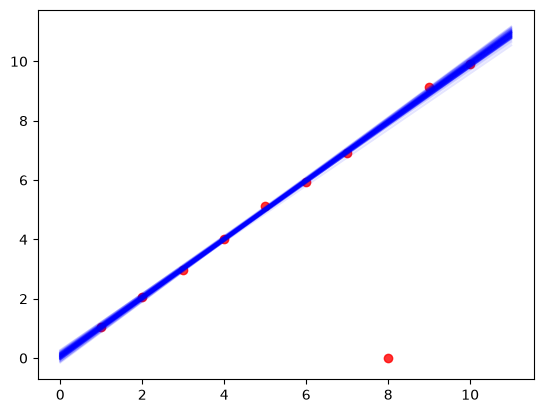

In [15]:
posterior_beta0 = idata.posterior['beta0'].values.flatten()
posterior_beta1 = idata.posterior['beta1'].values.flatten()

indices = np.random.choice(len(posterior_beta0), size=100, replace=False)

# Plot each line
x_vals = np.linspace(0, 11, 100)
for idx in indices:
    b0 = posterior_beta0[idx]
    b1 = posterior_beta1[idx]
    plt.plot(x_vals, b0 + b1 * x_vals, color='blue', alpha=0.1)

plt.scatter(X_data, Y_data, color='red', alpha=0.8)
#with the restricted degrees of freedom,
#the lines are a much better fit than before
#no longer shooting in random directions, mostly uniform

### Personal notes
- standard linear regression shifts or tilts regression line toward extreme outliers if they exist, messing with the main cluster.
- studen-t assign higher probabilities to points further from the mean. better avoids shifting and tilting from main cluster

# Ex5.5

In [74]:
radon = pd.read_csv("radon.txt", sep='\t')

radon

,log_radon,floor,county
0,0.788457,1,1
1,0.788457,0,1
2,1.064711,0,1
3,0.000000,0,1
4,1.131402,0,2
...,...,...,...
914,1.856298,0,84
915,1.504077,0,84
916,1.609438,0,84
917,1.308333,0,85


NUTS[nutpie]: [beta0, beta1, sigma]


Output()

Output()

         mean      sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
beta0  1.3267    0.03      1.3      1.4     7776     5809  1.00   0.00034  0.00032
beta1  -0.614   0.073    -0.73     -0.5     8211     6376  1.00    0.0008  0.00075
sigma  0.8235  0.0193     0.79     0.85    10960     6111  1.00   0.00018  0.00022


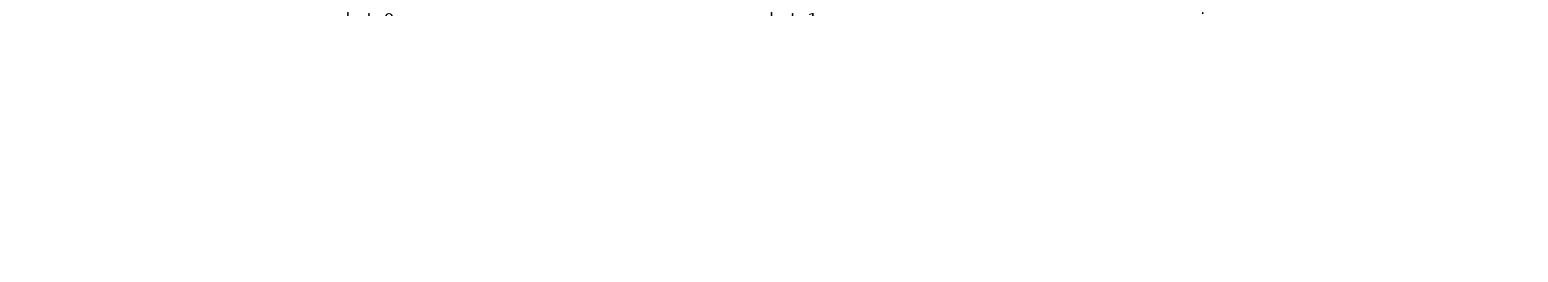

In [84]:
# --- Data and Hyperparameters ---
# The data for the exercise
X_data = np.array(radon["floor"])
Y_data = np.array(radon["log_radon"])


# Prior hyperparameters
beta0_mean = np.mean(Y_data)
beta1_mean = 0
beta_std = 9.0

# --- Model Definition ---
with pm.Model() as pooled_model:
    # Priors for the intercept (beta0) and slope (beta1)
    beta0 = pm.Normal('beta0', mu=beta0_mean, sigma=beta_std)
    beta1 = pm.Normal('beta1', mu=beta1_mean, sigma=beta_std)
    
    # Prior for the noise standard deviation
    sigma = pm.HalfNormal('sigma', sigma=5.0)
    
    # Expected value of Y
    mu = beta0 + beta1 * X_data
    
    # Likelihood of the data
    Y_obs = pm.Normal('Y_obs', mu=mu, sigma=sigma, observed=Y_data)
    idata = pm.sample(draws=2000, return_inferencedata=True)
    pm.compute_log_likelihood(idata)


az.plot_trace(idata)
summary = az.summary(idata, var_names=['beta0', 'beta1', 'sigma'])
print(summary)

In [76]:
posterior_beta0_mean = idata.posterior['beta0'].mean().item()
posterior_beta1_mean = idata.posterior['beta1'].mean().item()

radon['y predictions'] = posterior_beta0_mean + posterior_beta1_mean* X_data
radon['abs_error'] = np.abs(Y_data - radon['y predictions'])

county_errors = radon.groupby('county')['abs_error'].mean()
print(county_errors)
#different counties have different error rate, some higher others lower
#supposedly the geological locations are to blame, also nukes (probably)

county
1     0.551008
2     0.686242
3     0.484438
4     0.630493
5     0.377111
        ...   
81    1.311869
82    0.902957
83    0.687210
84    0.513130
85    0.140535
Name: abs_error, Length: 85, dtype: float64


In [85]:
counties = radon["county"].values - 1
n_counties = len(np.unique(counties))


# --- Model Definition ---
with pm.Model() as unpooled_model:
    # Priors for the intercept (beta0) and slope (beta1)
    beta0 = pm.Normal('beta0', mu=beta0_mean, sigma=beta_std, shape=n_counties)
    beta1 = pm.Normal('beta1', mu=beta1_mean, sigma=beta_std)
    
    # Prior for the noise standard deviation
    sigma = pm.HalfNormal('sigma', sigma=5.0)
    
    # Expected value of Y
    mu = beta0[counties] + beta1 * X_data
    
    # Likelihood of the data
    Y_obs = pm.Normal('Y_obs', mu=mu, sigma=sigma, observed=Y_data)
    idata_unpooled = pm.sample(draws=2000, return_inferencedata=True)
    pm.compute_log_likelihood(idata_unpooled)

az.plot_trace(idata_unpooled, var_names=['beta1', 'sigma'])
az.plot_trace(idata_unpooled, var_names=['beta0'], coords={'beta0_dim_0': [0, 1, 2, 3, 4]})
summary = az.summary(idata_unpooled, var_names=['beta0', 'beta1', 'sigma'])
print(summary)
#convergence seems fine still

NUTS[nutpie]: [beta0, beta1, sigma]


Output()

Output()

             mean      sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
beta0[0]    0.839   0.376     0.25      1.4    14628     6101  1.00    0.0031   0.0047
beta0[1]    0.874   0.105      0.7        1    14185     6140  1.00   0.00088   0.0014
beta0[2]    1.532    0.44     0.82      2.2    14501     5900  1.00    0.0037   0.0055
beta0[3]     1.55   0.287      1.1        2    12993     5958  1.00    0.0025   0.0036
beta0[4]    1.436   0.374     0.84        2    13904     6037  1.00    0.0032   0.0044
beta0[5]    1.509    0.44      0.8      2.2    14248     6035  1.00    0.0037   0.0057
beta0[6]    2.014   0.202      1.7      2.3    13751     5685  1.00    0.0017   0.0025
beta0[7]    1.989   0.388      1.4      2.6    13817     5965  1.00    0.0033   0.0049
beta0[8]    1.004   0.245     0.62      1.4    12685     6116  1.00    0.0022   0.0032
beta0[9]    1.568   0.307      1.1      2.1    13121     5727  1.00    0.0027   0.0038
beta0[10]   1.402   0.344     0.85        2

In [86]:
posterior_beta0_mean = idata_unpooled.posterior['beta0'].mean(dim=['chain', 'draw']).values
posterior_beta1_mean = idata_unpooled.posterior['beta1'].mean().item()

radon['y preds unpooled'] = posterior_beta0_mean[counties] + posterior_beta1_mean* X_data
radon['abs error unpooled'] = np.abs(Y_data - radon['y preds unpooled'])

county_errors = radon.groupby('county')['abs error unpooled'].mean()
print(county_errors)
#seems better

county
1     0.446517
2     0.579225
3     0.465051
4     0.520039
5     0.403794
        ...   
81    0.220847
82    0.011853
83    0.604719
84    0.393731
85    0.121811
Name: abs error unpooled, Length: 85, dtype: float64


In [90]:
loo_pooled = az.loo(idata)  # Model 1 (Complete Pooling)
loo_unpooled = az.loo(idata_unpooled)  # Model 2 (Varying Intercepts)

# Compare both models side-by-side
model_dict = {
    'Complete Pooling': idata,
    'Unpooled Intercepts': idata_unpooled
}

radon_compare = az.compare(model_dict)
print(radon_compare)
#complete Pooling is worse by 30 log-likelihood units
# the warning appears to be related to the counties with only a few observations 

/home/santa/Documents/github-repos/dscistats-exercises/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1169: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


                     rank  elpd_diff   dse  p_worse diag_diff    diag_elpd  \
Unpooled Intercepts     0        0.0   0.0      NaN            7 k̂ > 0.70   
Complete Pooling        1      -30.0  15.0     0.97                          

                        p    elpd    se  weight  
Unpooled Intercepts  86.9 -1100.0  28.0    0.68  
Complete Pooling      3.8 -1130.0  26.0    0.32  


/home/santa/Documents/github-repos/dscistats-exercises/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1169: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


### personal notes

- LOO-CV evaluates out-of-sample predictive accuracy